<a href="https://colab.research.google.com/github/apy9955/CODSOFT_Movie_Genre_Classification/blob/main/Movie_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving description.txt to description.txt
Saving test_data_solution.txt to test_data_solution.txt
Saving test_data.txt to test_data.txt
Saving train_data.txt to train_data.txt


In [4]:
# Load Training Dataset

train_data = pd.read_csv(
    "train_data.txt",
    sep=":::",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

# Show first 5 rows
train_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [5]:
# Dataset Information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  int64 
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-null  object
 3   DESCRIPTION  54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [6]:
# Check Missing Values
train_data.isnull().sum()

,0
ID,0
TITLE,0
GENRE,0
DESCRIPTION,0


In [7]:
# Check duplicate rows
train_data.duplicated().sum()

np.int64(0)

In [8]:
# Count movies in each genre
train_data["GENRE"].value_counts()

,count
GENRE,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


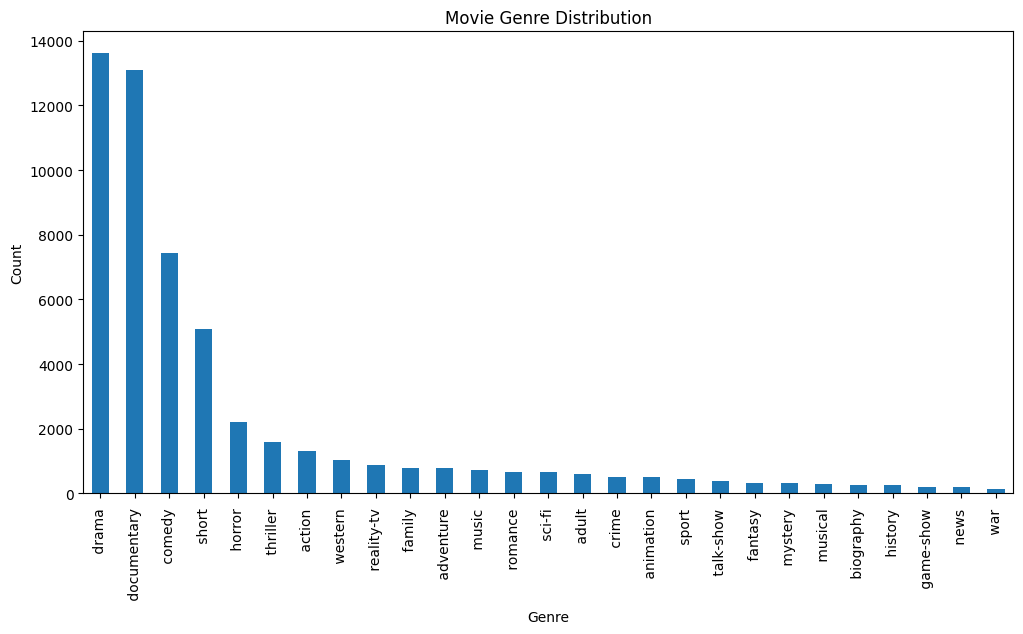

In [9]:
plt.figure(figsize=(12,6))
train_data["GENRE"].value_counts().plot(kind="bar")
plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [10]:
# Function to clean text

def clean_text(text):
    text = text.lower()                       # Convert to lowercase
    text = re.sub(r'http\S+', '', text)       # Remove URLs
    text = re.sub(r'\d+', '', text)           # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

In [11]:
# Apply text cleaning

train_data["DESCRIPTION"] = train_data["DESCRIPTION"].apply(clean_text)

# Check cleaned text
train_data["DESCRIPTION"].head()

,DESCRIPTION
0,listening in to a conversation between his doc...
1,a brother and sister with a past incestuous re...
2,as the bus empties the students for their fiel...
3,to help their unemployed father make ends meet...
4,the films title refers not only to the unrecov...


In [12]:
# Features and Target

X = train_data["DESCRIPTION"]
y = train_data["GENRE"]

In [13]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
# Train Model

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [16]:
# Predict

y_pred = model.predict(X_test_tfidf)

In [17]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 52.09 %


In [18]:
# Classification Report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

      action        0.56      0.08      0.13       263
       adult        1.00      0.05      0.10       112
   adventure        0.53      0.07      0.13       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.44      0.47      1443
       crime        0.00      0.00      0.00       107
 documentary        0.57      0.88      0.69      2659
       drama        0.46      0.83      0.59      2697
      family        1.00      0.01      0.01       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.15      0.26        40
     history        0.00      0.00      0.00        45
      horror        0.72      0.35      0.47       431
       music        0.83      0.13      0.23       144
     musical        0.00      0.00      0.00        50
     mystery        0.00      0.00      0.00        56
        n

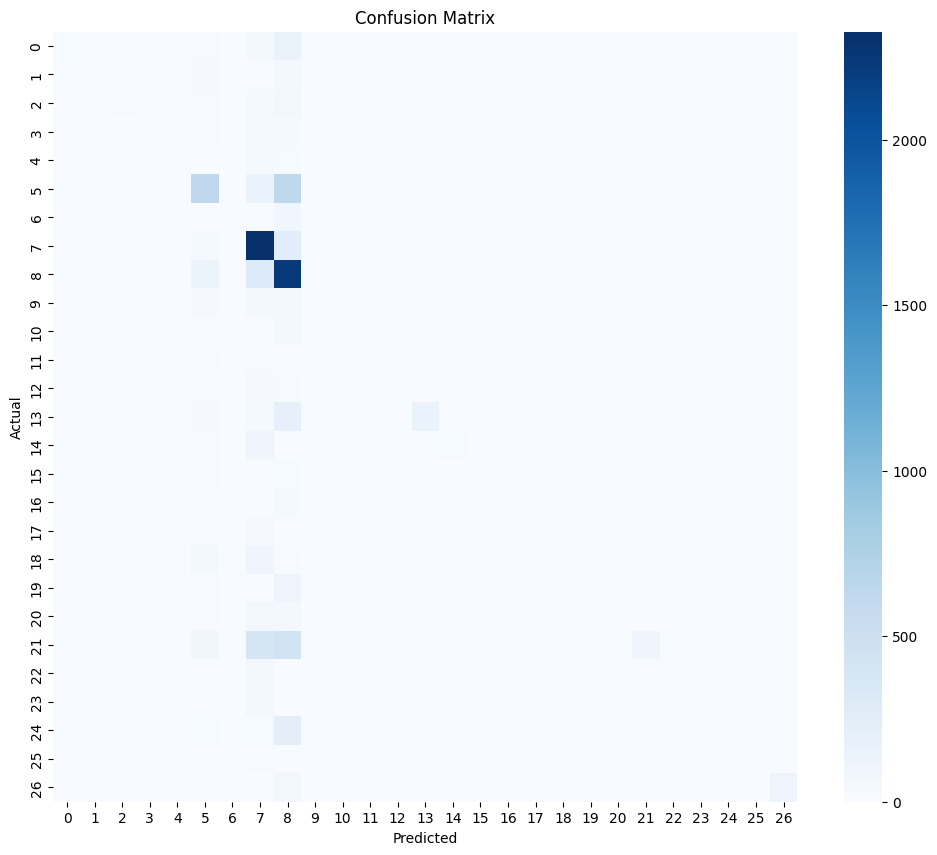

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression

# Create Model
lr_model = LogisticRegression(max_iter=1000)

# Train Model
lr_model.fit(X_train_tfidf, y_train)

# Prediction
lr_pred = lr_model.predict(X_test_tfidf)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")

# Classification Report
print(classification_report(y_test, lr_pred))

Accuracy: 57.59 %
               precision    recall  f1-score   support

      action        0.56      0.26      0.36       263
       adult        0.72      0.21      0.32       112
   adventure        0.45      0.14      0.21       139
   animation        0.67      0.10      0.17       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.58      0.54      1443
       crime        0.33      0.02      0.04       107
 documentary        0.66      0.84      0.74      2659
       drama        0.54      0.78      0.64      2697
      family        0.41      0.08      0.13       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.95      0.45      0.61        40
     history        0.00      0.00      0.00        45
      horror        0.62      0.56      0.59       431
       music        0.66      0.48      0.56       144
     musical        0.50      0.02      0.04        50
     mystery        0.00      0.00      0.00  

In [21]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

In [22]:
# Load Test Dataset

test_data = pd.read_csv(
    "test_data.txt",
    sep=":::",
    engine="python",
    names=["ID", "TITLE", "DESCRIPTION"]
)

test_data.head()

,ID,TITLE,DESCRIPTION
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),Before he was known internationally as a mart...


In [23]:
# Clean test descriptions

test_data["DESCRIPTION"] = test_data["DESCRIPTION"].apply(clean_text)

In [25]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [26]:
# Transform test data

X_final = tfidf.transform(test_data["DESCRIPTION"])

In [27]:
# Predict genres

predictions = model.predict(X_final)

test_data["Predicted_Genre"] = predictions

test_data.head(10)

,ID,TITLE,DESCRIPTION,Predicted_Genre
0,1,Edgar's Lunch (1998),lr brane loves his life his car his apartment ...,drama
1,2,La guerra de papá (1977),spain march quico is a very naughty child of t...,drama
2,3,Off the Beaten Track (2010),one year in the life of albin and his family o...,documentary
3,4,Meu Amigo Hindu (2015),his father has died he hasnt spoken with his b...,drama
4,5,Er nu zhai (1955),before he was known internationally as a marti...,drama
5,6,Riddle Room (2016),emily burns is being held captive in a room wi...,drama
6,7,L'amica (1969),the beautiful but neglected wife of a brillian...,drama
7,8,Ina Mina Dika (1989),vasu inamdar ina suffers from a disorder where...,drama
8,9,Equinox Special: Britain's Tornados (2005),an insight into the tornados that hit kensal r...,documentary
9,10,Press (2011),press is a story of young people overwhelmed b...,drama


In [28]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [29]:
import joblib

joblib.dump(model, "movie_genre_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [30]:
test_data.to_csv("movie_genre_predictions.csv", index=False)

print("Prediction file saved successfully!")

Prediction file saved successfully!


In [31]:
from google.colab import files

files.download("movie_genre_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("movie_genre_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
solution_data = pd.read_csv(
    "test_data_solution.txt",
    sep=":::",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

solution_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Edgar's Lunch (1998),thriller,"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),comedy,"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),documentary,One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),drama,"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),drama,Before he was known internationally as a mart...


In [34]:
# Clean solution descriptions
solution_data["DESCRIPTION"] = solution_data["DESCRIPTION"].apply(clean_text)

# True labels
y_true = solution_data["GENRE"]

# Predicted labels (jo pehle hi predict kar chuke ho)
y_pred = predictions

# Accuracy
from sklearn.metrics import accuracy_score, classification_report

print("Official Test Accuracy:", round(accuracy_score(y_true, y_pred) * 100, 2), "%")

# Classification Report
print(classification_report(y_true, y_pred))

Official Test Accuracy: 51.88 %
               precision    recall  f1-score   support

      action        0.60      0.08      0.14      1314
       adult        0.62      0.05      0.09       590
   adventure        0.77      0.08      0.14       775
   animation        0.00      0.00      0.00       498
   biography        0.00      0.00      0.00       264
      comedy        0.51      0.42      0.46      7446
       crime        0.00      0.00      0.00       505
 documentary        0.57      0.87      0.69     13096
       drama        0.46      0.83      0.59     13612
      family        0.00      0.00      0.00       783
     fantasy        0.00      0.00      0.00       322
   game-show        0.98      0.30      0.45       193
     history        0.00      0.00      0.00       243
      horror        0.69      0.32      0.44      2204
       music        0.75      0.10      0.18       731
     musical        0.00      0.00      0.00       276
     mystery        0.00      0.

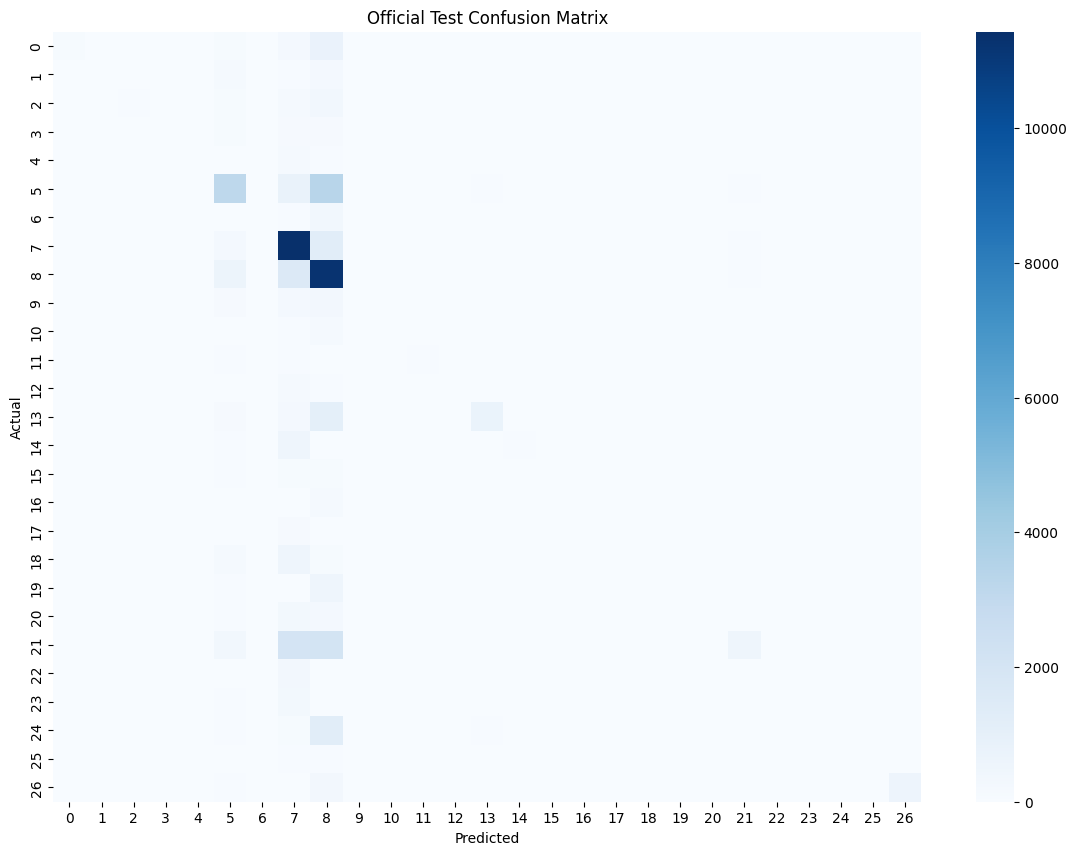

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Official Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
import joblib

joblib.dump(model, "movie_genre_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

test_data.to_csv("movie_genre_predictions.csv", index=False)

print("All files saved successfully!")

All files saved successfully!


In [37]:
from google.colab import files

files.download("movie_genre_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("movie_genre_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>